In [1]:
import json
import os
import random

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet50
from tqdm.auto import tqdm
from sklearn.metrics import f1_score  # criterio de best-checkpoint (F1-macro en validación)
import wandb  # pip install wandb, si no esta ya en el entorno del workstation

/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [3]:
SEED = 42


def seed_everything(seed=SEED):
    """Fija todas las fuentes de aleatoriedad del notebook.

    Cubre la init de la cabeza (linear1/bn1/linear2 en FullModel), el
    shuffle del DataLoader de train y la RandomRotation/RandomHorizontalFlip
    del train_transform (usan el RNG global de torch porque el DataLoader
    corre con num_workers=0). Mismo patrón que scripts/gen_lr_backbone_grid.py
    (exp10-exp19) — mantenerlo consistente si se copia esta celda a nuevos
    notebooks del bloque exp24+.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Determinismo en cuDNN: reproducible a costa de algo de velocidad.
    # Con benchmark=True cuDNN elige algoritmos según el hardware y la
    # misma semilla deja de dar el mismo resultado entre máquinas.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()
print(f"Semilla fijada: {SEED} (cudnn.deterministic=True, benchmark=False)")

Semilla fijada: 42 (cudnn.deterministic=True, benchmark=False)


In [4]:
EXP_ID = "exp41"
RUN_NAME = "exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler"
UNFROZEN_DESC = "todo el backbone descongelado"
BLOCK = 8  # bloque 8: muestreo balanceado por (source_dataset x clase) sobre la rejilla de profundidad del bloque 7
# Índices de backbone (nn.Sequential) a descongelar — ver freeze cell para el mapa completo.
UNFREEZE_IDX = [7, 6, 5, 4, 1, 0]
HEAD = "mlp"

# alpha del muestreador: w_i = n_celda ** (-SAMPLER_ALPHA). Con 1.0 las 8
# celdas (4 bases x 2 clases) quedan equiprobables y P(maligno|dataset)=0.5 en
# todas; con 0.0 se recupera el muestreo natural de los bloques 6/7.
SAMPLER_ALPHA = 1.0

LR = 1e-4            # cabeza (linear1/bn1/linear2)
LR_BACKBONE = 1e-4   # backbone descongelado — igual a LR y al del bloque 7, para que la rejilla compare 1-a-1
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 16
NUM_EPOCHS = 100
PATIENCE = 20
IMAGE_SIZE = 256
ROTATION_DEGREES = 7

PROJECT_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/"
    "Federal Learning/infraestructura federada/Federal-Learning"
)

DATASET_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/02-Databases/Mammo-Bench/"
    "c86fb00c-0fb8-4e0e-85a2-4d415f9c1ada_1a9410d8-9769-4064-a064-0160f2fd193d_"
    "DATASET-FILE_Mammo_Bench_zip_20241225112148174/Mammo_Data/Mammo-Bench"
)
MANIFEST_PATH = PROJECT_ROOT / "manifests" / "fedmammobench.csv"
RADIMAGENET_WEIGHTS_PATH = PROJECT_ROOT / "weights" / "RadImageNet-resnet50.pth"

# W&B: la API key NUNCA se pega aquí. Se lee de la variable de entorno
# WANDB_API_KEY, o de las credenciales cacheadas en ~/.netrc tras correr
# `wandb login` una vez en este workstation (a diferencia de los
# contenedores Docker del paquete, aqui el notebook SI hereda ese
# ~/.netrc porque corre directo en el host, sin aislar el filesystem).
WANDB_PROJECT = "fedmammobench"
WANDB_ENTITY = None  # None -> entity por defecto de la API key
WANDB_MODE = "online"  # "online" | "offline" | "disabled"
WANDB_TAGS = ["notebook", "centralized", "radimagenet", "mammobench", "all_unfrozen", "img256", "balanced-sampler"]

RUN_DIR = PROJECT_ROOT / "runs" / RUN_NAME
PLOTS_DIR = RUN_DIR / "plots"
# Métricas/gráficas globales (todo el test set) van en PLOTS_DIR y metrics.json.
# El desglose por source_dataset va aparte, en su propia carpeta, para no
# mezclar los dos niveles de granularidad.
PER_DATASET_DIR = RUN_DIR / "per_dataset"
RUN_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PER_DATASET_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RUN_DIR / "best_model.pth"
LAST_MODEL_PATH = RUN_DIR / "last_model.pth"

print(f"RUN_DIR: {RUN_DIR}")

RUN_DIR: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler


In [5]:
# W&B init. `WandbWriter` (src/fedmammobench/utils/wandb_utils.py) hace este
# mismo degradado en el paquete; aqui se replica a mano porque el notebook no
# importa fedmammobench. Nunca debe bloquear ni pedir la key por input():
# si no hay credenciales, cae a modo offline (o se desactiva del todo).
os.environ.setdefault("WANDB_SILENT", "true")

wandb_run = None
if WANDB_MODE != "disabled":
    mode = WANDB_MODE
    has_creds = bool(os.environ.get("WANDB_API_KEY", "").strip()) or bool(wandb.api.api_key)
    if mode == "online" and not has_creds:
        print(
            "No hay WANDB_API_KEY ni credenciales cacheadas (~/.netrc); "
            "corriendo wandb en modo offline. Sincroniza despues con "
            "`wandb sync` sobre la carpeta wandb/ de este run."
        )
        mode = "offline"

    try:
        wandb_run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=RUN_NAME,
            group=EXP_ID,
            tags=WANDB_TAGS,
            mode=mode,
            dir=str(RUN_DIR),
            config={
                "exp_id": EXP_ID,
                "seed": SEED,
                "block": BLOCK,
                "unfrozen": UNFROZEN_DESC,
                "unfreeze_idx": UNFREEZE_IDX,
                "head": HEAD,
                "loss": "CrossEntropyLoss",
                "class_weight": None,  # el balanceo lo hace el sampler, no la loss
                "sampler": "WeightedRandomSampler(source_dataset x clase)",
                "sampler_alpha": SAMPLER_ALPHA,
                "lr": LR,
                "lr_backbone": LR_BACKBONE if HEAD == "mlp" else None,
                "dropout": DROPOUT if HEAD == "mlp" else None,
                "weight_decay": WEIGHT_DECAY,
                "batch_size": BATCH_SIZE,
                "num_epochs": NUM_EPOCHS,
                "patience": PATIENCE,
                "image_size": IMAGE_SIZE,
                "rotation_degrees": ROTATION_DEGREES,
            },
        )
        print(f"W&B run ({mode}): {getattr(wandb_run, 'url', None) or RUN_DIR / 'wandb'}")
    except Exception as exc:
        print(f"wandb.init() fallo ({exc!r}); se continua sin W&B.")
        wandb_run = None
else:
    print("W&B desactivado (WANDB_MODE = 'disabled').")

W&B run (online): https://wandb.ai/j-mast8924-instituci-n-universitaria-itm/fedmammobench/runs/kcrd9odr


In [6]:
SPLIT_COL = "split"
LABEL_COL = "classification"
PATH_COL = "preprocessed_image_path"

TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = "train", "val", "test"


class CSVDataset(Dataset):
    def __init__(self, csv_file=None, split=None, root_dir="", transform=None, label_to_idx=None,
                 dataframe=None):
        if dataframe is not None:
            # Filas ya resueltas por el llamador (p.ej. un subset de test_processed.data
            # filtrado por source_dataset) — se usan tal cual, sin leer ni filtrar por split.
            self.data = dataframe.reset_index(drop=True)
        else:
            self.data = pd.read_csv(csv_file)

            missing = {SPLIT_COL, LABEL_COL, PATH_COL} - set(self.data.columns)
            if missing:
                raise KeyError(
                    f"El manifest {csv_file} no tiene la(s) columna(s) {sorted(missing)}. "
                    f"Columnas disponibles: {list(self.data.columns)}"
                )

            available = sorted(self.data[SPLIT_COL].dropna().unique())
            if split not in available:
                raise ValueError(
                    f"split={split!r} no existe en la columna {SPLIT_COL!r}. "
                    f"Valores disponibles: {available}"
                )

            self.data = self.data[self.data[SPLIT_COL] == split].reset_index(drop=True)

        if len(self.data) == 0:
            source = f"split {split!r}" if dataframe is None else "el dataframe recibido"
            raise ValueError(f"El dataset quedó vacío ({source}).")

        self.root_dir = Path(root_dir)
        self.transform = transform

        if label_to_idx is None:
            labels = sorted(self.data[LABEL_COL].unique())
            self.label_to_idx = {label: i for i, label in enumerate(labels)}
        else:
            self.label_to_idx = label_to_idx

        unknown = set(self.data[LABEL_COL].unique()) - set(self.label_to_idx)
        if unknown:
            raise ValueError(
                f"Hay etiquetas {sorted(unknown)} ausentes en label_to_idx={self.label_to_idx}."
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = Path(self.root_dir) / Path(row[PATH_COL])
        image = Image.open(img_path).convert("RGB")

        label = self.label_to_idx[row[LABEL_COL]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
_manifest = pd.read_csv(MANIFEST_PATH)

_required = {SPLIT_COL, LABEL_COL, PATH_COL}
assert _required <= set(_manifest.columns), (
    f"Faltan columnas en el manifest: {sorted(_required - set(_manifest.columns))}"
)

_splits = sorted(_manifest[SPLIT_COL].dropna().unique())
assert set(_splits) >= {TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT}, (
    f"El manifest solo tiene splits {_splits}; se esperaban "
    f"{[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]}"
)

print(f"Filas totales: {len(_manifest)}\n")
print(pd.crosstab(_manifest[SPLIT_COL], _manifest[LABEL_COL], margins=True))

if "source_dataset" in _manifest.columns:
    print()
    print(pd.crosstab(_manifest["source_dataset"], _manifest[SPLIT_COL], margins=True))

Filas totales: 8341

classification  Benign  Malignant   All
split                                  
test               557        277   834
train             4393       2278  6671
val                555        281   836
All               5505       2836  8341

split           test  train  val   All
source_dataset                        
cdd-cesm         100    803  100  1003
cmmd             472   3776  474  4722
inbreast          40    328   42   410
kau-bcmd         222   1764  220  2206
All              834   6671  836  8341


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [9]:
train_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TRAIN_SPLIT, root_dir=DATASET_ROOT,
    transform=train_transform,
)
validation_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=VAL_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)
test_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TEST_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)

print(f"label_to_idx: {train_processed.label_to_idx}")
print(f"train: {len(train_processed)} | val: {len(validation_processed)} | test: {len(test_processed)}")

label_to_idx: {'Benign': 0, 'Malignant': 1}
train: 6671 | val: 836 | test: 834


In [10]:
# Muestreo balanceado por celda (source_dataset x clase) — la regularización
# central de este bloque. En train, P(maligno | dataset) va de 0.046 (kau-bcmd)
# a 0.489 (cmmd), asi que identificar la base de origen (trivial: escáner,
# preprocesado, histograma) reduce la loss sin mirar la lesión. Los resultados
# del bloque 7 lo confirman: sobre las imágenes BENIGNAS del test, la
# probabilidad media que emite el modelo correlaciona r=0.98 con la prevalencia
# de su base de origen — el modelo aprendió P(maligno | dataset), no la lesión.
#
# w_i = n_c ** (-SAMPLER_ALPHA), con c = celda (source_dataset, clase) de la
# imagen i. Con alpha=1 las 8 celdas quedan equiprobables => P(maligno|dataset)
# = 0.5 en las cuatro => la identidad de la base deja de informar la etiqueta y
# el atajo se queda sin gradiente: la unica via para bajar la loss es separar
# maligno de benigno DENTRO de cada dominio.
_loader_generator = torch.Generator()
_loader_generator.manual_seed(SEED)


def _seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# transform("size") difunde el tamaño del grupo a cada fila SIN reordenar, y eso
# es imprescindible: CSVDataset.__getitem__ usa self.data.iloc[idx] (indexación
# posicional) y WeightedRandomSampler indexa por esa misma posición, o sea que
# w[i] tiene que corresponder a train_processed[i]. Un merge o un
# groupby().apply() pueden reordenar y desalinearían los pesos en silencio.
_cell_sizes = (
    train_processed.data
    .groupby(["source_dataset", LABEL_COL])[LABEL_COL]
    .transform("size")
    .to_numpy()
)
_sample_weights = _cell_sizes.astype(np.float64) ** (-SAMPLER_ALPHA)
_sample_weights = _sample_weights / _sample_weights.mean()  # media 1: solo legibilidad

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(_sample_weights, dtype=torch.double),
    num_samples=len(train_processed),  # misma longitud de época que exp28-exp36: mismos pasos/época
    replacement=True,                  # obligatorio para sobremuestrear las celdas raras
    generator=_loader_generator,       # el sorteo consume RNG; sembrarlo como el shuffle que sustituye
)

# drop_last=True: la cabeza usa BatchNorm1d, que revienta si el último batch de
# la época queda con 1 sola muestra.
# Sin shuffle=True: es incompatible con sampler, y el sampler ya aporta la
# aleatoriedad.
# val/test SIN sampler: la evaluación tiene que ver la distribución natural o
# las métricas son ficción.
train = DataLoader(
    train_processed, batch_size=BATCH_SIZE, sampler=train_sampler, drop_last=True,
    worker_init_fn=_seed_worker,
)
validation = DataLoader(validation_processed, batch_size=BATCH_SIZE, shuffle=False)
test = DataLoader(test_processed, batch_size=BATCH_SIZE, shuffle=False)

# Verificación de alineación: si los pesos estuvieran desplazados respecto al
# orden posicional del Dataset, el sampler sobremuestrearía imágenes
# equivocadas y nada avisaría. Sorteamos una época con un generator aparte (no
# perturbar el de train) y miramos la composición que sale.
_check_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(_sample_weights, dtype=torch.double),
    num_samples=len(train_processed), replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)
_idx = np.fromiter(iter(_check_sampler), dtype=np.int64)
_drawn = train_processed.data.iloc[_idx]
_malignant = sorted(train_processed.label_to_idx, key=train_processed.label_to_idx.get)[1]
print(f"SAMPLER_ALPHA={SAMPLER_ALPHA} | pesos {_sample_weights.min():.3f}..{_sample_weights.max():.3f} "
      f"(ratio {_sample_weights.max() / _sample_weights.min():.1f}x)")
print(f"únicas por época: {len(np.unique(_idx))}/{len(train_processed)} "
      f"({len(np.unique(_idx)) / len(train_processed) * 100:.0f}%)")
print(f"P({_malignant} | dataset) en el sorteo (objetivo 0.500 con alpha=1):")
for _ds, _row in pd.crosstab(_drawn["source_dataset"], _drawn[LABEL_COL], normalize="index").iterrows():
    print(f"  {_ds:10} {_row.get(_malignant, 0.0):.3f}")
del _check_sampler, _idx, _drawn

SAMPLER_ALPHA=1.0 | pesos 0.432..10.169 (ratio 23.5x)
únicas por época: 3076/6671 (46%)
P(Malignant | dataset) en el sorteo (objetivo 0.500 con alpha=1):
  cdd-cesm   0.501
  cmmd       0.488
  inbreast   0.505
  kau-bcmd   0.498


In [11]:
class Classifier(nn.Module):
    def __init__(self, num_class):
        super().__init__()
        self.linear = nn.Linear(2048, num_class)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)


class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = resnet50(weights=None)
        encoder_layers = list(base_model.children())
        self.backbone = nn.Sequential(*encoder_layers[:9])

    def forward(self, x):
        return self.backbone(x)

In [12]:
def load_radimagenet_backbone(weights_path, device="cpu"):
    model = resnet50(weights=None)
    checkpoint = torch.load(weights_path, map_location=device)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    # RadImageNet-resnet50.pth guarda el backbone como nn.Sequential, así que
    # sus claves son "backbone.0.weight" en vez de "conv1.weight". Sin este
    # remap, load_state_dict(strict=False) casa CERO claves y deja el modelo
    # en su init aleatorio sin avisar.
    backbone_remap = {
        "backbone.0.": "conv1.",
        "backbone.1.": "bn1.",
        "backbone.4.": "layer1.",
        "backbone.5.": "layer2.",
        "backbone.6.": "layer3.",
        "backbone.7.": "layer4.",
    }
    remapped_state_dict = {}
    for k, v in state_dict.items():
        new_k = k
        for old_prefix, new_prefix in backbone_remap.items():
            if k.startswith(old_prefix):
                new_k = new_prefix + k[len(old_prefix):]
                break
        remapped_state_dict[new_k] = v
    state_dict = remapped_state_dict

    state_dict = {
        k: v for k, v in state_dict.items()
        if k.startswith(("conv1", "bn1", "relu", "maxpool", "layer1", "layer2", "layer3", "layer4", "avgpool"))
    }

    if len(state_dict) == 0:
        raise RuntimeError(
            "0 RadImageNet tensors matched the model after remapping — "
            "check the checkpoint's key format before continuing."
        )

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Loaded {len(state_dict)} RadImageNet tensors into the backbone.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # Trunca a conv1..avgpool para que la salida (batch, 2048, 1, 1) encaje
    # con el Linear(2048, ...) del clasificador.
    encoder_layers = list(model.children())
    return nn.Sequential(*encoder_layers[:9])


backbone = load_radimagenet_backbone(RADIMAGENET_WEIGHTS_PATH, device=device).to(device)

Loaded 318 RadImageNet tensors into the backbone.
Missing keys: ['fc.weight', 'fc.bias']
Unexpected keys: []


In [13]:
# Índices de backbone (nn.Sequential, ver backbone_remap en load_radimagenet_backbone):
# 0=conv1, 1=bn1, 4=layer1, 5=layer2, 6=layer3, 7=layer4 (2=relu/3=maxpool/8=avgpool
# no tienen parámetros). UNFREEZE_IDX se fija en la celda de parámetros — esta celda
# es la misma para las 5 profundidades del bloque, solo cambia UNFREEZE_IDX.
for param in backbone.parameters():
    param.requires_grad = False
for idx in UNFREEZE_IDX:
    for param in backbone[idx].parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total = sum(p.numel() for p in backbone.parameters())
pct = 100 * trainable / total
print(f"[{EXP_ID}] Backbone trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")

[exp41] Backbone trainable params: 23,508,032 / 23,508,032 (100.00%)


In [14]:
train_loss_history = []
val_loss_history = []
val_f1_history = []


def freeze_bn_running_stats(module):
    # requires_grad=False congela gamma/beta pero NO running_mean/running_var,
    # que se siguen actualizando en cada forward en modo train(). eval() las fija.
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d) and not m.weight.requires_grad:
            m.eval()


def train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS, sheduler=None,
                patience=PATIENCE):
    # Best-checkpoint y early stopping se rigen por F1-macro en validación, no
    # por la loss: con clases desbalanceadas la loss puede seguir bajando
    # (el modelo se vuelve más "seguro") mientras el F1 de la clase minoritaria
    # empeora, así que es un mejor criterio de "mejor modelo" que la loss sola.
    best_val_f1 = -1.0
    train_loss_history.clear()
    val_loss_history.clear()
    val_f1_history.clear()
    counter = 0
    best_epoch = 0

    epoch_bar = tqdm(range(num_epochs), desc="Epochs", unit="epoch")
    for e in epoch_bar:
        train_loss = 0.0
        model.train()
        freeze_bn_running_stats(model)
        train_bar = tqdm(train, desc=f"  train {e+1}/{num_epochs}", unit="batch", leave=False)
        for data, labels in train_bar:
            # CrossEntropyLoss espera índices de clase (long), no floats.
            data, labels = data.to(device, dtype=torch.float), labels.to(device, dtype=torch.long)

            optimizer.zero_grad()
            target = model(data)
            loss = criterion(target, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        valid_loss = 0.0
        val_preds_epoch, val_labels_epoch = [], []
        model.eval()
        val_bar = tqdm(validation, desc=f"  val   {e+1}/{num_epochs}", unit="batch", leave=False)
        with torch.no_grad():
            for data, labels in val_bar:
                data, labels = data.to(device, dtype=torch.float), labels.to(device, dtype=torch.long)

                target = model(data)
                loss = criterion(target, labels)
                valid_loss += loss.item()
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

                val_preds_epoch.extend(torch.argmax(target, dim=1).cpu().numpy())
                val_labels_epoch.extend(labels.cpu().numpy())

        avg_train_loss = train_loss / len(train)
        avg_valid_loss = valid_loss / len(validation)
        avg_valid_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="macro")
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_valid_loss)
        val_f1_history.append(avg_valid_f1)
        epoch_bar.set_postfix(
            train_loss=f"{avg_train_loss:.4f}", val_loss=f"{avg_valid_loss:.4f}", val_f1=f"{avg_valid_f1:.4f}",
        )

        if wandb_run is not None:
            wandb_run.log(
                {
                    "train/loss": avg_train_loss,
                    "val/loss": avg_valid_loss,
                    "val/f1_macro": avg_valid_f1,
                },
                step=e + 1,
            )

        print(
            f"Epoch {e+1} \t\t Training Loss: {avg_train_loss} \t\t "
            f"Validation Loss: {avg_valid_loss} \t\t Validation F1-macro: {avg_valid_f1:.6f}"
        )

        torch.save(model.state_dict(), LAST_MODEL_PATH)

        if avg_valid_f1 > best_val_f1:
            print(f"Validation F1-macro increased({best_val_f1:.6f}--->{avg_valid_f1:.6f}) \t Saving The Model")
            best_val_f1 = avg_valid_f1
            best_epoch = e + 1
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            counter = 0
        else:
            counter += 1
            print(f"EarlyStopping counter: {counter} out of {patience}")

        if counter >= patience:
            print(f"Early stopping triggered en la época {e+1}. Mejor época: {best_epoch}.")
            break

        if sheduler is not None:
            sheduler.step()

    print(f"\nMejor época: {best_epoch} (val F1-macro {best_val_f1:.6f}) -> {BEST_MODEL_PATH}")
    print(f"Última época: {len(train_loss_history)} -> {LAST_MODEL_PATH}")
    return model

In [15]:
class FullModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.linear1  = nn.Linear(2048, 512)
        self.bn1      = nn.BatchNorm1d(512)
        self.act1     = nn.ReLU(inplace=True)
        self.dropout1 = nn.Dropout(p=DROPOUT)

        self.linear2  = nn.Linear(512, 512)
        self.bn2      = nn.BatchNorm1d(512)
        self.act2     = nn.ReLU(inplace=True)
        self.dropout2 = nn.Dropout(p=DROPOUT)

        # 2 logits (benigno/maligno) para CrossEntropyLoss, en vez de 1 logit
        # + sigmoid (BCEWithLogitsLoss).
        self.linear3  = nn.Linear(512, 2)

    def forward(self, x):

        x = self.backbone(x)
        x = x.view(x.size(0), -1) 
         
        x = self.linear1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.linear2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        x = self.linear3(x)
        return x  # logits [batch, 2] crudos; CrossEntropyLoss aplica softmax internamente


# Re-sembrar aquí hace que los pesos iniciales de la cabeza (linear1/bn1/
# linear2/bn2/linear3) no dependan de cuántas celdas se hayan ejecutado antes
# (Jupyter permite ejecutarlas en cualquier orden, y el RNG global es estado
# compartido).
seed_everything()  # pesos iniciales de la cabeza reproducibles
model = FullModel(backbone).to(device)

# linear1/linear2/linear3 se reinicializan con una distribución normal en vez
# del kaiming_uniform por defecto de nn.Linear — incluyendo linear3, que es la
# capa de salida real de esta cabeza de 2 capas ocultas (el loop original solo
# cubria linear1/linear2 porque se copio de la cabeza de 1 capa oculta, donde
# linear2 SI era la salida; sin este fix linear3 quedaba con el init Kaiming
# de PyTorch -- std ~2.5x mayor y bias no nulo -- justo en la unica capa que
# alimenta a CrossEntropyLoss sin ningun BatchNorm detras que absorba la
# escala, a diferencia de linear1/linear2 que si tienen bn1/bn2 despues).
# bn1/bn2 se dejan en su default (gamma=1, beta=0); el backbone ya trae pesos
# RadImageNet y no se toca aqui.
for m in (model.linear1, model.linear2, model.linear3):
    nn.init.normal_(m.weight, mean=0.0, std=0.01)
    nn.init.zeros_(m.bias)

In [16]:
# SIN class_weight en la loss: el balanceo lo hace el WeightedRandomSampler de
# la celda de DataLoaders, que ya deja P(maligno)=0.5 DENTRO de cada base.
# Aplicar encima los pesos inversos a la frecuencia global (lo que hacían
# exp34-exp36, [0.683, 1.317]) contaría el balanceo dos veces y sobreponderaría
# maligno en ~1.93x, reintroduciendo justo el desplazamiento de umbral que este
# bloque busca eliminar.
criterion = nn.CrossEntropyLoss()

# Grupos de parámetros dinámicos: recoge lo que haya quedado con
# requires_grad=True en el backbone (cualquiera que sea UNFREEZE_IDX) en vez
# de apuntar a un índice fijo (backbone[7]) — así esta celda no cambia entre
# las 5 profundidades del bloque, solo la celda de freeze.
backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
head_params = (
    list(model.linear1.parameters())
    + list(model.bn1.parameters())
    + list(model.linear2.parameters())
)

param_groups = [{"params": head_params, "lr": LR, "name": "head"}]
if backbone_params:
    param_groups.append({"params": backbone_params, "lr": LR_BACKBONE, "name": "backbone"})

optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
sheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Optimizer: AdamW(lr_head={LR}, lr_backbone={LR_BACKBONE if backbone_params else None}, weight_decay={WEIGHT_DECAY})")
for g in optimizer.param_groups:
    n = sum(p.numel() for p in g["params"])
    print(f"  grupo {g['name']:9} lr={g['lr']:<8} params={n:,}")
print(f"Parámetros entrenables: {sum(p.numel() for p in trainable_params):,}")

Optimizer: AdamW(lr_head=0.0001, lr_backbone=0.0001, weight_decay=0.0001)
  grupo head      lr=0.0001   params=1,312,768
  grupo backbone  lr=0.0001   params=23,508,032
Parámetros entrenables: 24,822,850


In [17]:
model = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS,
                    sheduler=sheduler, patience=PATIENCE)

Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

  train 1/100:   0%|          | 0/416 [00:00<?, ?batch/s]

  val   1/100:   0%|          | 0/53 [00:00<?, ?batch/s]

Epoch 1 		 Training Loss: 0.6360608840074676 		 Validation Loss: 0.5915292557680382 		 Validation F1-macro: 0.653324


Validation F1-macro increased(-1.000000--->0.653324) 	 Saving The Model


...

EarlyStopping counter: 19 out of 20


  train 51/100:   0%|          | 0/416 [00:00<?, ?batch/s]

  val   51/100:   0%|          | 0/53 [00:00<?, ?batch/s]

Epoch 51 		 Training Loss: 0.12554308690596372 		 Validation Loss: 0.4945434624294065 		 Validation F1-macro: 0.756353


EarlyStopping counter: 20 out of 20
Early stopping triggered en la época 51. Mejor época: 31.

Mejor época: 31 (val F1-macro 0.770839) -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/best_model.pth
Última época: 51 -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/last_model.pth


Epoch   1 	 Training Loss: 0.636061 	 Validation Loss: 0.591529 	 Validation F1-macro: 0.653324
Epoch   2 	 Training Loss: 0.522203 	 Validation Loss: 0.588316 	 Validation F1-macro: 0.680636
Epoch   3 	 Training Loss: 0.439647 	 Validation Loss: 0.558670 	 Validation F1-macro: 0.695019
Epoch   4 	 Training Loss: 0.381107 	 Validation Loss: 0.514306 	 Validation F1-macro: 0.705501
Epoch   5 	 Training Loss: 0.341476 	 Validation Loss: 0.526176 	 Validation F1-macro: 0.705589
Epoch   6 	 Training Loss: 0.315052 	 Validation Loss: 0.519832 	 Validation F1-macro: 0.717480
Epoch   7 	 Training Loss: 0.291507 	 Validation Loss: 0.508844 	 Validation F1-macro: 0.730953
Epoch   8 	 Training Loss: 0.269195 	 Validation Loss: 0.517579 	 Validation F1-macro: 0.736479
Epoch   9 	 Training Loss: 0.243854 	 Validation Loss: 0.501977 	 Validation F1-macro: 0.732606
Epoch  10 	 Training Loss: 0.244713 	 Validation Loss: 0.513379 	 Validation F1-macro: 0.736495
Epoch  11 	 Training Loss: 0.230825 	 Va

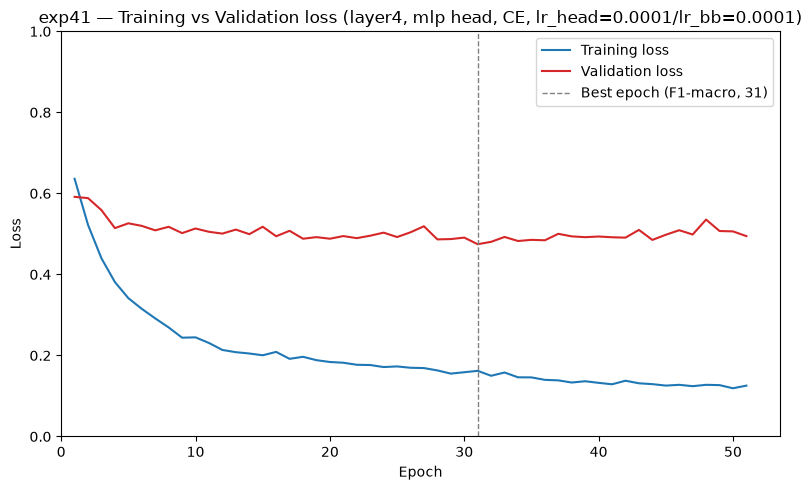

In [18]:
import matplotlib.pyplot as plt

best_epoch = int(np.argmax(val_f1_history)) + 1

for epoch, (t_loss, v_loss, v_f1) in enumerate(zip(train_loss_history, val_loss_history, val_f1_history), start=1):
    marker = "  <-- best (max val F1-macro)" if epoch == best_epoch else ""
    print(
        f"Epoch {epoch:3d} \t Training Loss: {t_loss:.6f} \t Validation Loss: {v_loss:.6f} "
        f"\t Validation F1-macro: {v_f1:.6f}{marker}"
    )

loss_history_path = RUN_DIR / "loss_history.csv"
pd.DataFrame({
    "epoch": range(1, len(train_loss_history) + 1),
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
    "val_f1_macro": val_f1_history,
}).to_csv(loss_history_path, index=False)
print(f"\nHistorial guardado en: {loss_history_path}")

fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, len(train_loss_history) + 1)
ax.plot(epochs_range, train_loss_history, label="Training loss", color="#1f77b4")
ax.plot(epochs_range, val_loss_history, label="Validation loss", color="#d62728")
ax.axvline(best_epoch, linestyle="--", color="gray", lw=1, label=f"Best epoch (F1-macro, {best_epoch})")
ax.set_xlim(left=0)
ax.set_ylim(0, 1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"{EXP_ID} — Training vs Validation loss (layer4, mlp head, CE, lr_head={LR}/lr_bb={LR_BACKBONE})")
ax.legend()
fig.tight_layout()

loss_curve_path = PLOTS_DIR / "loss_curve.png"
fig.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {loss_curve_path}")
plt.show()

In [19]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)


def evaluate_model(model, checkpoint_path, dataloader, device=device, desc="eval"):
    """Carga `checkpoint_path` en `model` y lo evalúa sobre `dataloader`.

    El caller arma el DataLoader (el `test` de todo el split, o uno nuevo sobre el
    subset de un solo source_dataset — ver celda de abajo) y elige con qué checkpoint
    evaluar; esta función solo hace inferencia + métricas, sin construir datasets ni
    decidir qué filas evaluar, así que sirve igual para el desglose global o por dataset.
    """
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    labels, preds, probs = [], [], []
    with torch.no_grad():
        for data, lbl in tqdm(dataloader, desc=desc, unit="batch", leave=False):
            data = data.to(device, dtype=torch.float)
            logits = model(data)
            p = torch.softmax(logits, dim=1)
            pred = torch.argmax(logits, dim=1)

            labels.extend(lbl.numpy())
            preds.extend(pred.cpu().numpy())
            # p[:, 1] = P(clase 1), score que roc_auc_score espera en binario.
            probs.extend(p[:, 1].cpu().numpy())

    n = len(labels)
    result = {"n_samples": n, "labels": labels, "preds": preds, "probs": probs}
    if n == 0 or len(set(labels)) < 2:
        # AUC/precision/recall/F1 no están bien definidos con una sola clase presente (o 0 muestras).
        result["warning"] = "menos de 2 clases en este subset; AUC/precision/recall/F1 se omiten"
        result["accuracy"] = float(accuracy_score(labels, preds)) if n else None
        result["auc"] = result["precision"] = result["recall"] = result["f1"] = None
    else:
        result["accuracy"] = float(accuracy_score(labels, preds))
        result["auc"] = float(roc_auc_score(labels, probs))
        result["precision"] = float(precision_score(labels, preds, pos_label=1, zero_division=0))
        result["recall"] = float(recall_score(labels, preds, pos_label=1, zero_division=0))
        result["f1"] = float(f1_score(labels, preds, pos_label=1, zero_division=0))
    result["confusion_matrix"] = confusion_matrix(labels, preds, labels=[0, 1]).tolist()
    return result


def save_predictions_csv(manifest_df, result, out_path):
    """Guarda `manifest_df` (las mismas filas que se evaluaron) con 3 columnas nuevas:
    y_true (índice de clase real), y_pred (índice de clase predicho) y y_prob
    (P(clase 1) — el mismo score que roc_auc_score y la curva ROC usan).

    y_true/y_pred/y_prob se asignan por posición, no por índice de fila, así que
    `manifest_df` debe conservar el mismo orden de fila que vio el DataLoader
    (shuffle=False, igual que en toda esta sección) — CSVDataset(dataframe=...) no
    reordena filas, solo resetea el índice, así que esto vale tanto para
    test_processed.data (global) como para un subset filtrado por source_dataset.
    """
    out_df = manifest_df.copy()
    out_df["y_true"] = result["labels"]
    out_df["y_pred"] = result["preds"]
    out_df["y_prob"] = result["probs"]
    out_df.to_csv(out_path, index=False)
    print(f"Predicciones guardadas en: {out_path}")
    return out_path


idx_to_label = {v: k for k, v in train_processed.label_to_idx.items()}
global_result = evaluate_model(model, BEST_MODEL_PATH, test, desc="Test (global)")
all_labels, all_preds, all_probs = global_result["labels"], global_result["preds"], global_result["probs"]
test_acc, test_auc = global_result["accuracy"], global_result["auc"]

save_predictions_csv(test_processed.data, global_result, RUN_DIR / "predictions.csv")

print(f"label_to_idx: {train_processed.label_to_idx}  (clase positiva para AUC = {idx_to_label[1]!r})")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC AUC:  {test_auc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=[idx_to_label[0], idx_to_label[1]]))

Test (global):   0%|          | 0/53 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/predictions.csv
label_to_idx: {'Benign': 0, 'Malignant': 1}  (clase positiva para AUC = 'Malignant')
Test accuracy: 0.7698
Test ROC AUC:  0.8357

              precision    recall  f1-score   support

      Benign       0.81      0.86      0.83       557
   Malignant       0.67      0.60      0.63       277

    accuracy                           0.77       834
   macro avg       0.74      0.73      0.73       834
weighted avg       0.76      0.77      0.77       834



Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/plots/test_confusion_matrix.png


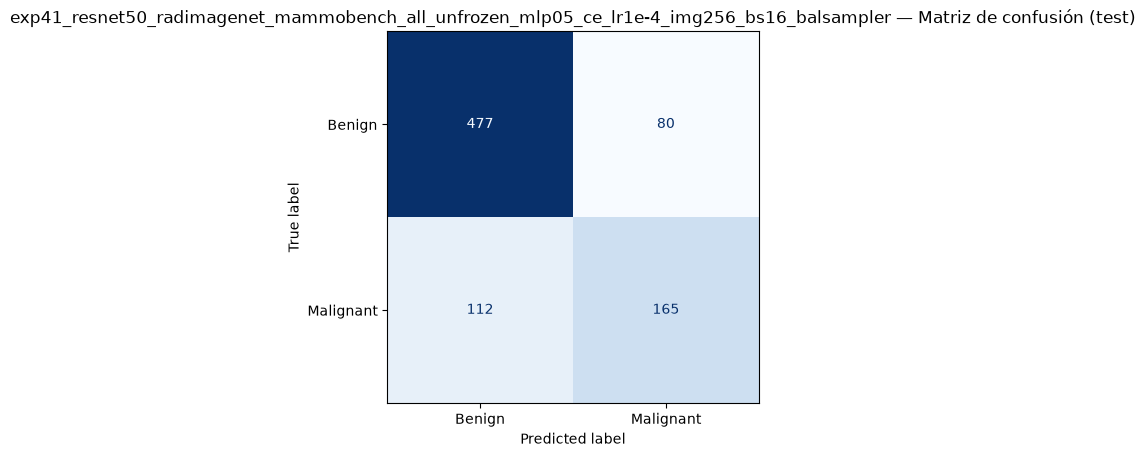

Accuracy  : 0.7698
ROC AUC   : 0.8357
Precision : 0.6735
Recall    : 0.5957
F1-score  : 0.6322


Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/plots/test_roc_curve.png


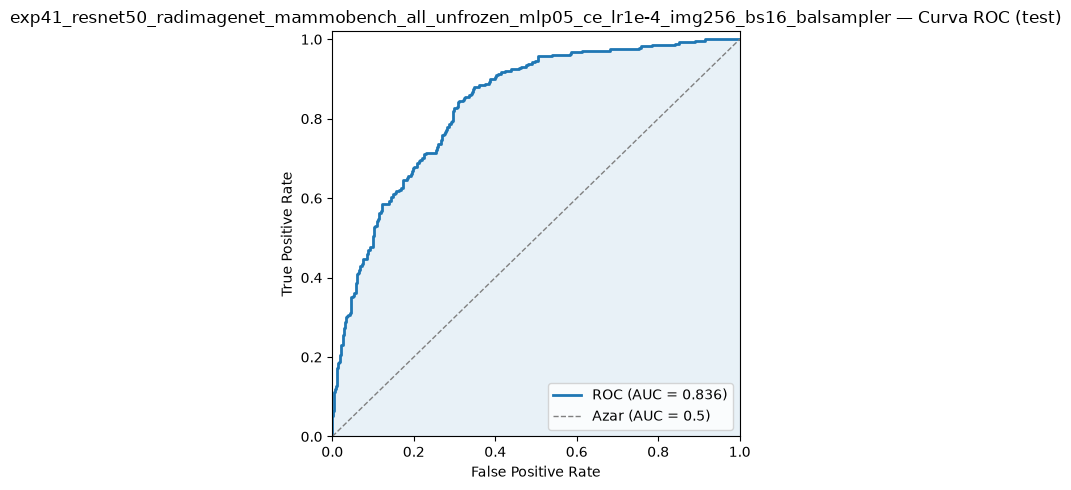

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/plots/test_metrics_bar.png


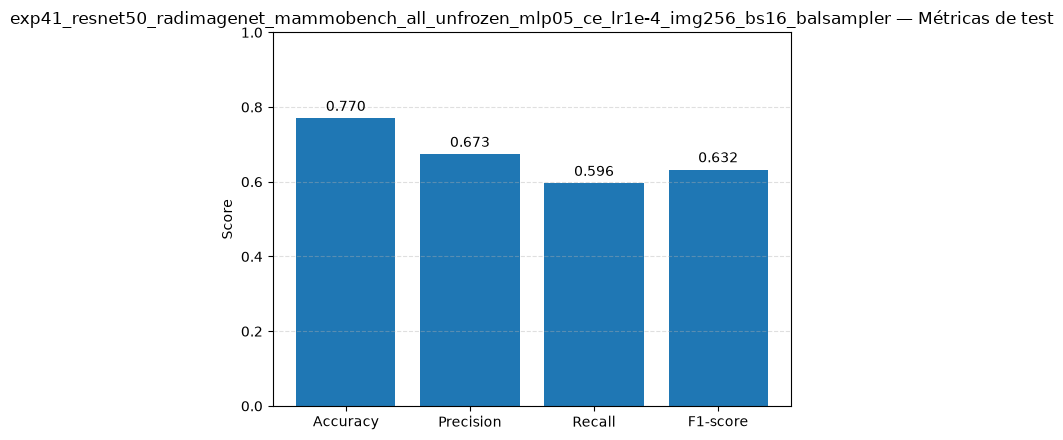

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_curve

test_precision = precision_score(all_labels, all_preds, pos_label=1)
test_recall = recall_score(all_labels, all_preds, pos_label=1)
test_f1 = f1_score(all_labels, all_preds, pos_label=1)
cm = confusion_matrix(all_labels, all_preds)

class_names = [idx_to_label[0], idx_to_label[1]]

fig_cm, ax_cm = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title(f"{RUN_NAME} — Matriz de confusión (test)")
fig_cm.tight_layout()

cm_path = PLOTS_DIR / "test_confusion_matrix.png"
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {cm_path}")
plt.show()

metrics = {
    "Accuracy": test_acc,
    "ROC AUC": test_auc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
}
for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

if wandb_run is not None:
    wandb_run.log({f"test/{k.lower().replace(' ', '_')}": v for k, v in metrics.items()})
    wandb_run.summary["best_epoch"] = best_epoch
    wandb_run.summary["best_val_loss"] = min(val_loss_history)
    wandb_run.summary["best_val_f1_macro"] = max(val_f1_history)

# ROC AUC es el area bajo la curva ROC: se grafica la curva real, no un punto suelto.
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig_roc, ax_roc = plt.subplots(figsize=(5, 5))
ax_roc.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC (AUC = {test_auc:.3f})")
ax_roc.fill_between(fpr, tpr, alpha=0.1, color="#1f77b4")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Azar (AUC = 0.5)")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title(f"{RUN_NAME} — Curva ROC (test)")
ax_roc.legend(loc="lower right")
fig_roc.tight_layout()

roc_path = PLOTS_DIR / "test_roc_curve.png"
fig_roc.savefig(roc_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {roc_path}")
plt.show()

# Accuracy/Precision/Recall/F1 son escalares puntuales en el mismo rango [0, 1]: se
# comparan mejor juntos en un solo grafico de barras que en 4 graficos de un punto.
bar_metrics = {k: v for k, v in metrics.items() if k != "ROC AUC"}

fig_bar, ax_bar = plt.subplots(figsize=(6, 4.5))
bars = ax_bar.bar(bar_metrics.keys(), bar_metrics.values(), color="#1f77b4")
ax_bar.set_ylim(0, 1)
ax_bar.set_ylabel("Score")
ax_bar.set_title(f"{RUN_NAME} — Métricas de test")
ax_bar.grid(True, axis="y", linestyle="--", alpha=0.4)
ax_bar.bar_label(bars, fmt="%.3f", padding=3)
fig_bar.tight_layout()

bar_path = PLOTS_DIR / "test_metrics_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {bar_path}")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test/confusion_matrix": wandb.Image(str(cm_path)),
        "test/roc_curve": wandb.Image(str(roc_path)),
        "test/metrics_bar": wandb.Image(str(bar_path)),
    })
# wandb_run.finish() se movió al final de la sección per-dataset (más abajo),
# para poder seguir logueando a este mismo run mientras se calcula el desglose.

In [21]:
summary = {
    "experiment": EXP_ID,
    "block": BLOCK,
    "run_name": RUN_NAME,
    "unfrozen": UNFROZEN_DESC,
    "unfreeze_idx": UNFREEZE_IDX,
    "seed": SEED,
    "hyperparams": {
        "head": HEAD,
        "dropout": DROPOUT if HEAD == "mlp" else None,
        "lr": LR,
        "lr_backbone": LR_BACKBONE,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "patience": PATIENCE,
        "image_size": IMAGE_SIZE,
        "optimizer": "AdamW",
        "loss": "CrossEntropyLoss",
        "class_weight": None,  # balanceo por sampler, no por loss
        "sampler": "WeightedRandomSampler(source_dataset x clase, replacement=True)",
        "sampler_alpha": SAMPLER_ALPHA,
        "scheduler": "CosineAnnealingLR",
        "augmentation": f"RandomRotation({ROTATION_DEGREES}) + RandomHorizontalFlip(p=0.5)",
        "seed": SEED,
        "best_checkpoint_metric": "val_f1_macro",
    },
    "epochs_run": len(train_loss_history),
    "best_epoch": best_epoch,
    "best_val_loss": float(min(val_loss_history)),
    "best_val_f1_macro": float(max(val_f1_history)),
    "final_train_loss": float(train_loss_history[-1]),
    "final_val_loss": float(val_loss_history[-1]),
    "test": {
        "accuracy": float(test_acc),
        "auc": float(test_auc),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),
        "confusion_matrix": cm.tolist(),
        "class_names": class_names,
    },
    # Desglose por source_dataset (cmmd/kau-bcmd/cdd-cesm/inbreast): archivo aparte,
    # calculado en las celdas de abajo, no inline aquí — ver PER_DATASET_DIR.
    "per_dataset_metrics_path": str(PER_DATASET_DIR / "metrics_per_dataset.json"),
    "checkpoints": {
        "best": str(BEST_MODEL_PATH),
        "last": str(LAST_MODEL_PATH),
    },
}

metrics_path = RUN_DIR / "metrics.json"
metrics_path.write_text(json.dumps(summary, indent=2))
print(f"Resumen guardado en: {metrics_path}")
print(json.dumps(summary["test"], indent=2))

Resumen guardado en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/metrics.json
{
  "accuracy": 0.7697841726618705,
  "auc": 0.8357173875000812,
  "precision": 0.673469387755102,
  "recall": 0.5956678700361011,
  "f1": 0.632183908045977,
  "confusion_matrix": [
    [
      477,
      80
    ],
    [
      112,
      165
    ]
  ],
  "class_names": [
    "Benign",
    "Malignant"
  ]
}


In [22]:
per_dataset_metrics = {}
for name in sorted(test_processed.data["source_dataset"].unique()):
    subset_df = test_processed.data[test_processed.data["source_dataset"] == name]
    subset_dataset = CSVDataset(
        dataframe=subset_df, root_dir=DATASET_ROOT, transform=val_transform,
        label_to_idx=train_processed.label_to_idx,
    )
    subset_loader = DataLoader(subset_dataset, batch_size=BATCH_SIZE, shuffle=False)

    result = evaluate_model(model, BEST_MODEL_PATH, subset_loader, desc=f"Test ({name})")
    save_predictions_csv(subset_df, result, PER_DATASET_DIR / f"predictions_{name}.csv")
    for key in ("labels", "preds", "probs"):
        result.pop(key, None)  # ya están volcadas al csv de predicciones; no hacen falta en el json de métricas
    per_dataset_metrics[name] = result

for name, m in per_dataset_metrics.items():
    print(f"--- {name} (n={m['n_samples']}) ---")
    for k, v in m.items():
        if k not in ("confusion_matrix", "n_samples"):
            print(f"  {k:10s}: {v}")
    print()

if wandb_run is not None:
    for name, m in per_dataset_metrics.items():
        wandb_run.log({
            f"test_per_dataset/{name}/{k}": v
            for k, v in m.items()
            if isinstance(v, (int, float))
        })

per_dataset_metrics_path = PER_DATASET_DIR / "metrics_per_dataset.json"
per_dataset_metrics_path.write_text(json.dumps(per_dataset_metrics, indent=2))
print(f"Métricas por dataset guardadas en: {per_dataset_metrics_path}")

Test (cdd-cesm):   0%|          | 0/7 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/per_dataset/predictions_cdd-cesm.csv


Test (cmmd):   0%|          | 0/30 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/per_dataset/predictions_cmmd.csv


Test (inbreast):   0%|          | 0/3 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/per_dataset/predictions_inbreast.csv


Test (kau-bcmd):   0%|          | 0/14 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/per_dataset/predictions_kau-bcmd.csv
--- cdd-cesm (n=100) ---
  accuracy  : 0.82
  auc       : 0.8914518317503393
  precision : 0.7777777777777778
  recall    : 0.6363636363636364
  f1        : 0.7

--- cmmd (n=472) ---
  accuracy  : 0.6610169491525424
  auc       : 0.7137261947538629
  precision : 0.6666666666666666
  recall    : 0.6086956521739131
  f1        : 0.6363636363636364

--- inbreast (n=40) ---
  accuracy  : 0.825
  auc       : 0.859375
  precision : 0.6666666666666666
  recall    : 0.25
  f1        : 0.36363636363636365

--- kau-bcmd (n=222) ---
  accuracy  : 0.9684684684684685
  auc       : 0.537037037037037
  precision : 0.4
  recall    : 0.3333333333333333
  f1        : 0.36363636363636365

Métricas por dataset guardadas en

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/per_dataset/test_metrics_per_dataset.png


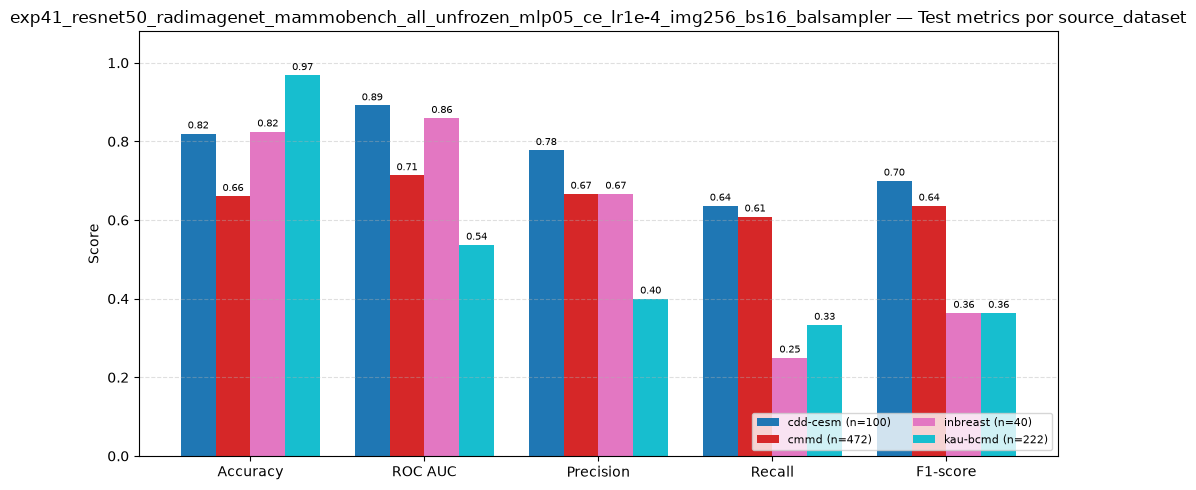

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp41_resnet50_radimagenet_mammobench_all_unfrozen_mlp05_ce_lr1e-4_img256_bs16_balsampler/per_dataset/test_confusion_matrix_per_dataset.png


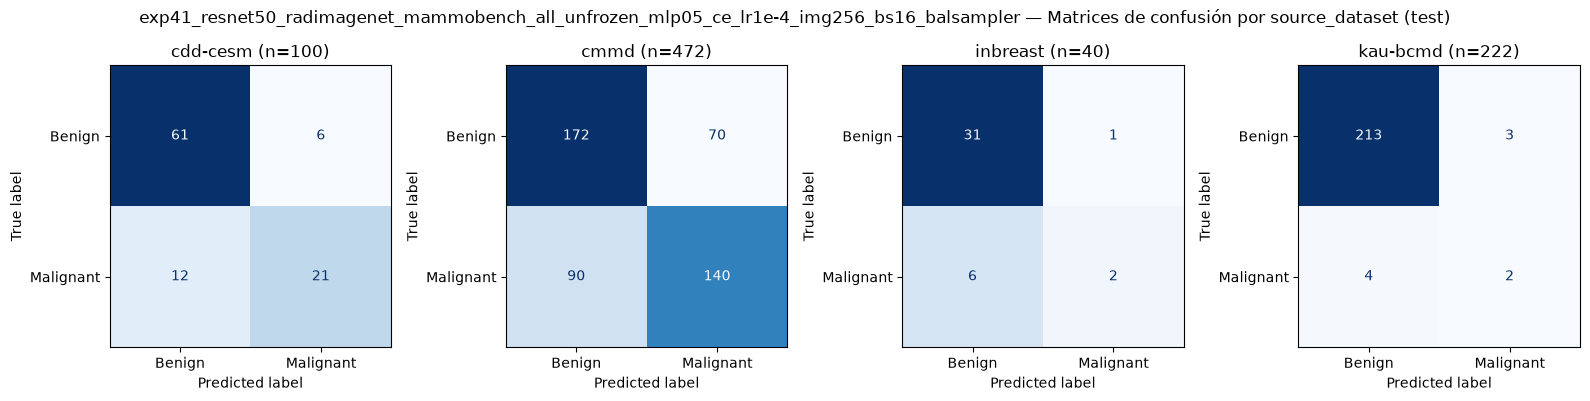

In [23]:
dataset_names = list(per_dataset_metrics.keys())
metric_keys = ["accuracy", "auc", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "ROC AUC", "Precision", "Recall", "F1-score"]

# Barras agrupadas: un grupo por métrica, una barra por dataset — las 5 métricas
# viven en [0, 1], así que se leen mejor juntas que en 5 gráficos sueltos.
fig_bar, ax_bar = plt.subplots(figsize=(10, 5))
x = np.arange(len(metric_keys))
width = 0.8 / len(dataset_names)
colors = plt.cm.tab10(np.linspace(0, 1, len(dataset_names)))

for i, name in enumerate(dataset_names):
    values = [per_dataset_metrics[name][k] or 0.0 for k in metric_keys]
    offset = (i - (len(dataset_names) - 1) / 2) * width
    bars = ax_bar.bar(
        x + offset, values, width,
        label=f"{name} (n={per_dataset_metrics[name]['n_samples']})", color=colors[i],
    )
    ax_bar.bar_label(bars, fmt="%.2f", padding=2, fontsize=7)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_labels)
ax_bar.set_ylim(0, 1.08)
ax_bar.set_ylabel("Score")
ax_bar.set_title(f"{RUN_NAME} — Test metrics por source_dataset")
ax_bar.legend(loc="lower right", fontsize=8, ncol=2)
ax_bar.grid(axis="y", linestyle="--", alpha=0.4)
fig_bar.tight_layout()

per_dataset_bar_path = PER_DATASET_DIR / "test_metrics_per_dataset.png"
fig_bar.savefig(per_dataset_bar_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {per_dataset_bar_path}")
plt.show()

# Una matriz de confusión por dataset, en una sola grilla para comparar de un vistazo.
n_ds = len(dataset_names)
fig_cm2, axes_cm2 = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4))
if n_ds == 1:
    axes_cm2 = [axes_cm2]
for ax_cm2, name in zip(axes_cm2, dataset_names):
    cm_ds = np.array(per_dataset_metrics[name]["confusion_matrix"])
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_ds, display_labels=class_names)
    disp2.plot(ax=ax_cm2, cmap="Blues", colorbar=False, values_format="d")
    ax_cm2.set_title(f"{name} (n={per_dataset_metrics[name]['n_samples']})")
fig_cm2.suptitle(f"{RUN_NAME} — Matrices de confusión por source_dataset (test)")
fig_cm2.tight_layout()

per_dataset_cm_path = PER_DATASET_DIR / "test_confusion_matrix_per_dataset.png"
fig_cm2.savefig(per_dataset_cm_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {per_dataset_cm_path}")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test_per_dataset/metrics_bar": wandb.Image(str(per_dataset_bar_path)),
        "test_per_dataset/confusion_matrices": wandb.Image(str(per_dataset_cm_path)),
    })
    wandb_run.finish()